In [1]:
"""
Script Name: extract_HUB_data.py
Authores: Walter Arredondo, Carlos Daza, Andrés Coral
Fecha: 2026-10-03
Fase ETL: Extracción
Descripción:
Extrae los datos de Capacidad, generación y consumo de electricidad de HUB de Energia,
https://hubenergia.org/index.php/es/indicators/capacidad-generacion-y-consumo-de-electricidad
realiza un Análisis Exploratorio de Datos (EDA) y los datos originales son guardados
como archivo CSV para posterior transformación.
Entradas: - Base de datos HUB de origen xlsx
Salidas: - Archivos CSV con los datos de las 3 hojas HUB:
* data/raw/extract_HUB_consumo.csv *
* data/raw/extract_HUB_generacion_electrica.csv *
* data/raw/extract_HUB_capacidad_instalada.csv *
Notas: - Ejecutar este script una sola vez - La API es de acceso público.
"""

'\nScript Name: extract_HUB_data.py\nAuthores: Walter Arredondo, Carlos Daza, Andrés Coral\nFecha: 2026-10-03\nFase ETL: Extracción\nDescripción:\nExtrae los datos de Capacidad, generación y consumo de electricidad de HUB de Energia,\nhttps://hubenergia.org/index.php/es/indicators/capacidad-generacion-y-consumo-de-electricidad\nrealiza un Análisis Exploratorio de Datos (EDA) y los datos originales son guardados\ncomo archivo CSV para posterior transformación.\nEntradas: - Base de datos HUB de origen xlsx\nSalidas: - Archivos CSV con los datos de las 3 hojas HUB:\n* data/raw/HUB_consumo.csv *\n* data/raw/HUB_generacion_electrica.csv *\n* data/raw/HUB_capacidad_instalada.csv *\nNotas: - Ejecutar este script una sola vez - La API es de acceso público.\n'

# Extracción de los datos

A continuación se realiza los import, creación de variables, importar el archivo xlsx y  extraer los datos requeridos.

In [2]:
# Imports necesarios para la extracción de datos
from google.colab import drive
import time
import pandas as pd

In [3]:
# Montar Google Drive para acceder al archivo
drive.mount('/content/drive')

# Definir la ruta del archivo xlsx en Google Drive
ruta_base = "/content/drive/My Drive/Colab Notebooks/Master/1.ETL/entregable3/data/original/"
ruta_xlsx = ruta_base + "hub.xlsx"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Este dataset se divide en 3 hojas


*   Generación_eléctrica
*   Capacidad_instalada
*   Consumo

 se considera usar los 20 países con mayor consumo de América Latina y un rango de tiempo entre 2000-2021


In [4]:
# filtrar solo 20 paises
paises = [
    'Brasil', 'México', 'Argentina', 'Chile', 'Colombia',
    'Perú', 'Venezuela', 'Ecuador', 'República Dominicana',
    'Paraguay', 'Uruguay', 'Guatemala', 'Costa Rica', 'Panamá',
    'Bolivia', 'Honduras', 'El Salvador', 'Nicaragua', 'Cuba',
    'Haiti'
]

# HOJA 1 " Generación_eléctrica"

In [5]:
# guardar dataset en la variable df.
# crear un pandas dataframe, se usa pagina 'Generación_eléctrica'
df1 = pd.read_excel(ruta_xlsx, sheet_name='Generación_eléctrica',skiprows=7)
# Visualizar dataframe.
df1.head()

,Indicador,Fuente,País,Año,Valor,Unidad
0,Generación eléctrica por fuente,Hidro,Guatemala,1991,1811.49,GWh
1,Generación eléctrica por fuente,Térmica no renovable,Guatemala,1991,651.90,GWh
2,Generación eléctrica por fuente,Nuclear,Guatemala,1991,NaN,GWh
3,Generación eléctrica por fuente,Geotermia,Guatemala,1991,0.00,GWh
4,Generación eléctrica por fuente,Eólica,Guatemala,1991,0.00,GWh


In [6]:
#Aplicacíon filtros
filtro_anos = df1['Año'].between(2000, 2021)
filtro_paises = df1['País'].isin(paises)
#Dataset filtrado
df_filtrado = df1[filtro_anos & filtro_paises].copy()

Verificar numero de registros por cada País y total

In [7]:
# conteo original
print("Conteo total de registros para los 20 países:")
total_paises = df_filtrado['País'].isin(paises).sum()
print(total_paises)
# Ver el número de registros por cada uno de los 20 países
print("\nRegistros por país:")
print(df_filtrado[df_filtrado['País'].isin(paises)]['País'].value_counts())

Conteo total de registros para los 20 países:
3960

Registros por país:
País
Argentina               198
Bolivia                 198
Brasil                  198
Chile                   198
Colombia                198
Costa Rica              198
Cuba                    198
Ecuador                 198
El Salvador             198
Guatemala               198
Haiti                   198
Honduras                198
México                  198
Nicaragua               198
Panamá                  198
Paraguay                198
Perú                    198
República Dominicana    198
Uruguay                 198
Venezuela               198
Name: count, dtype: int64


## Análisis Exploratorio de Datos (EDA) HOJA 1

Se realiza el EDA para tener mayor conocimiento sobre la información de la hoja 1 del dataset, a saber:


*   Cantidad de filas y columnas obtenidas
*   Tipos de datos y cantidad de registros por columnas
*   Registros nulos
*   Valores constantes
*   Unidades de medida
*   Estadísticas descriptivas
*   Patrones temporales

In [8]:
import matplotlib.pyplot as plt

In [9]:
#instalar
!pip uninstall -y pandas-profiling
!pip install ydata-profiling
!pip install numba==0.58.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 36.7 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned abo

In [10]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_3083/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [11]:
# Verificar la cantidad de registros y el número de columnas del dataframe df_filtrado
df_filtrado.shape

(3960, 6)

Al final se obtienen 3960 registros con 6 columnas en la hoja 1.

In [12]:
# Conocer nombres de las columnas, cantidad de registros y tipos de datos del dataframe df_filtrado
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3960 entries, 243 to 6821
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Indicador  3960 non-null   object 
 1   Fuente     3960 non-null   object 
 2   País       3960 non-null   object 
 3   Año        3960 non-null   int64  
 4   Valor      2663 non-null   float64
 5   Unidad     3960 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 216.6+ KB


El dataset Generación_eléctrica se compone de:


*   Indicador : De tipo descriptivo "Generación eléctica por fuente" .
*   Fuente: Categoria o tipo de enérgia " Hidro - Térmica no renovable - Nuclear - Geotermia - Eólica - Solar - Otros - Térmica renovable -Total".
*   País: Nombre del país.
*   Año:  Año de registro.
*  Valor: Cantidad de energía generada.
*  Unidad: unidad en la que fue medida GWh.

se eliminan columnas redundantes o que no aportan información relevante al EDA



Eliminación de Ruido

In [13]:
# eliminar columnas redundantes
df1_limpio = df_filtrado.drop(columns=['Indicador','Unidad'])
# Verificar la cantidad de registros y el número de columnas del dataframe df_limpio
df1_limpio.shape

(3960, 4)

In [14]:
# Generar perfilamiento de datos con Pandas Profiling
# nombre unico
nombre_archivo = f"reporte_generación_electrica_{int(time.time())}.html"
profile = ProfileReport(df1_limpio, title="Análisis Exploratorio - Generación Electrica- Dataset")
profile.to_file(nombre_archivo)
#mostar datset
#profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 17.87it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Ver valores faltantes o nulos

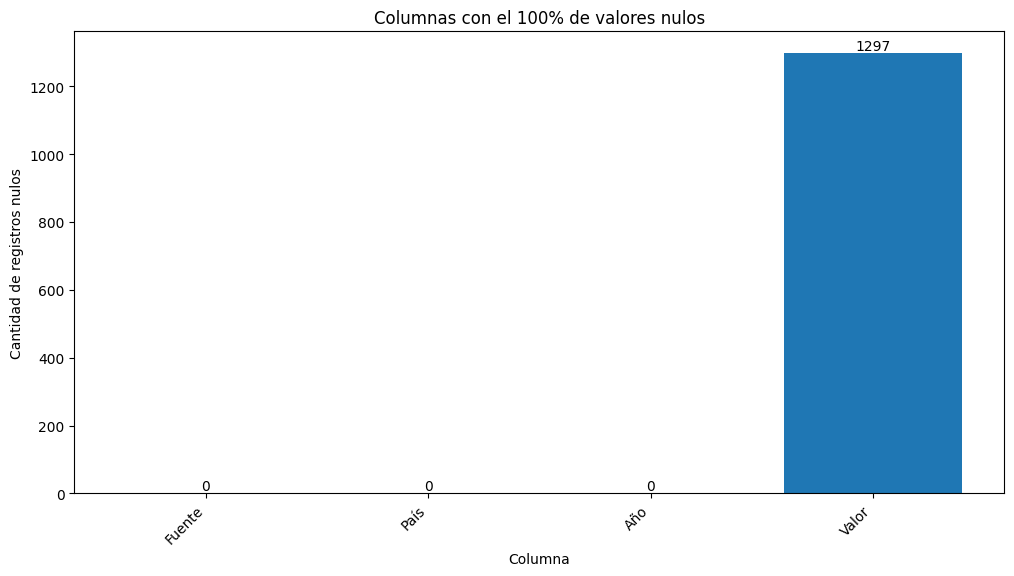

In [15]:
# Crear el DataFrame de análisis de nulos
nulos = pd.DataFrame({
    "Columna": df1_limpio.columns,
    "Cantidad de nulos": df1_limpio.isna().sum(),
    "Porcentaje de nulos": df1_limpio.isna().mean() * 100
})

# Configuración del gráfico de barras
plt.figure(figsize = (12, 6))
plt.bar(nulos["Columna"], nulos["Cantidad de nulos"])
plt.title("Columnas con el 100% de valores nulos")
plt.xlabel("Columna")
plt.ylabel("Cantidad de registros nulos")
plt.xticks(rotation=45, ha = "right")

# Mostrar el valor encima de cada barra
for i, valor in enumerate(nulos["Cantidad de nulos"]):
    plt.text(i, valor, str(valor), ha="center", va="bottom")

# Mostrar el gráfico
plt.show()

Un valor nulo es la ausencia de un valor o la falta de información de un dato, para este caso la columna valor tiene valores "nulos" que representa ciertas fuentes de energia, las cuales no registraron valores porque no se genero energia o en ese periodo de tiempo no existia la infraestructura requerida.

Estadisticas Descriptivas

In [16]:
# Tabla descriptiva por fuente
tabla_descriptiva = df1_limpio.groupby('Fuente')['Valor'].agg(
    Conteo='count',
    Nulos=lambda x: x.isna().sum(),
    Pct_Nulos=lambda x: (x.isna().sum() / len(x)) * 100,
    Media='mean',
    Desv_Estd='std',
    Minimo='min',
    Mediana='median',
    Maximo='max'
).round(2).reset_index()

# Mostrar la tabla formateada
display(tabla_descriptiva)

,Fuente,Conteo,Nulos,Pct_Nulos,Media,Desv_Estd,Minimo,Mediana,Maximo
0,Eólica,341,99,22.50,1829.68,7410.61,0.00,61.00,72285.97
1,Geotermia,198,242,55.00,1042.95,1864.82,0.00,248.31,7403.85
2,Hidro,440,0,0.00,34286.96,78644.40,48.30,7202.44,428332.92
3,Nuclear,110,330,75.00,6246.56,5719.39,0.00,6695.91,16128.82
4,Otros,64,376,85.45,136.60,472.17,0.00,0.00,2206.51
5,Solar,326,114,25.91,476.23,2103.87,0.00,0.83,20194.19
6,Total,440,0,0.00,65218.37,119195.56,506.13,15207.82,656109.15
7,Térmica no renovable,440,0,0.00,25084.82,47969.89,0.42,5755.36,254496.00
8,Térmica renovable,304,136,30.91,2930.79,9555.48,0.00,410.28,58741.85


La tabla muestra el diagnostico del consumo por sector económico de los 20 paises observados durante el periodo analizado (2000-2021) se identifica:



*  Hidro presenta el máximo de registros con un promedio de 34.286,96 Gwh y un valor Máximo de 42.8332,92 Gwh, reflejando la dependencia hídrica regional. Este comportamiento tambien se observa con Térmica no renovable siendo este el respaldo en la generación eléctrica.
* Eólica y solar presentan un valor menor de registros esto se debe a su incorporación a partir de la década de 2010.
* La presencia de valores Nulos en Geotérmica y Nuclear muestran las restricciones de infraestructura y ubicación geográfica puesto que pocos paises son capaces de generar dichas energías.





In [17]:
import seaborn as sns

/tmp/ipykernel_3083/1160425032.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_pais, x='Valor', y='País', palette='Blues_r')


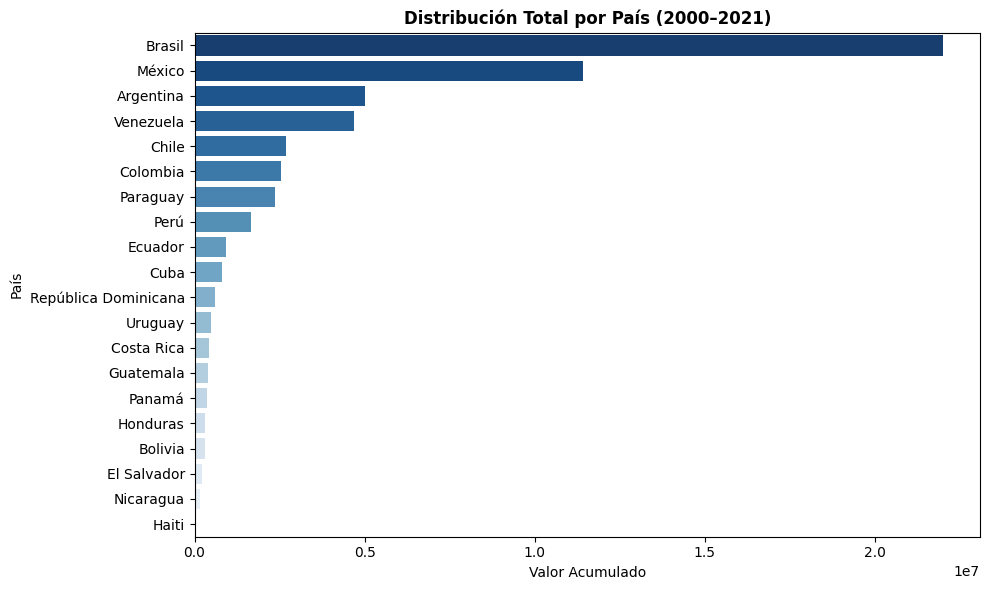

In [18]:
#distribucion por pais
dist_pais = df1_limpio.groupby('País')['Valor'].sum().reset_index()
dist_pais = dist_pais.sort_values('Valor', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=dist_pais, x='Valor', y='País', palette='Blues_r')

plt.title('Distribución Total por País (2000–2021)', fontweight='bold')
plt.xlabel('Valor Acumulado')
plt.tight_layout()
plt.show()

Se observa una Asimetría en la escala, la concentración máxima de generación, capacidad y consumo se encuentran en los Paises de Brasil y México.

Patrones temporales

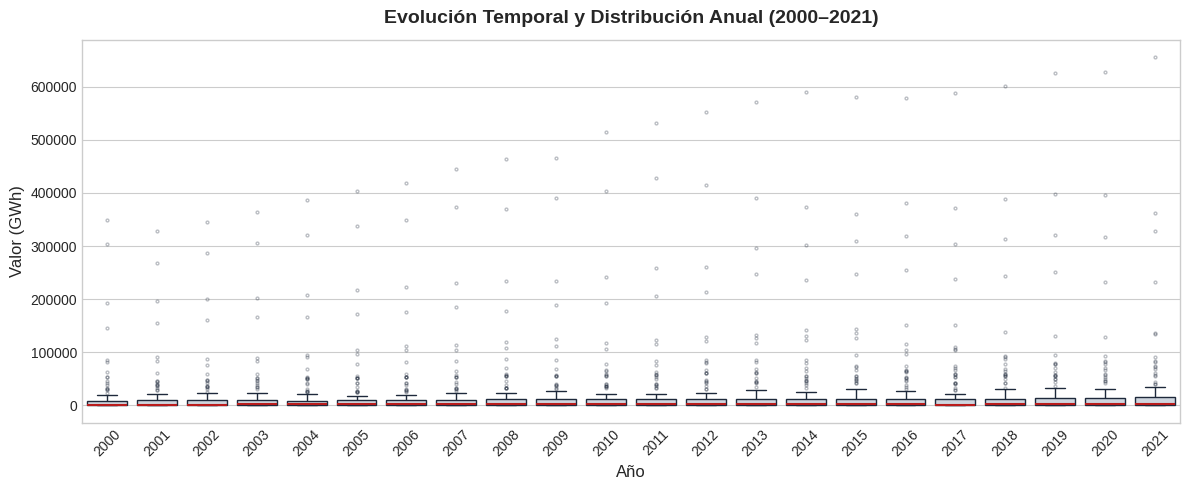

In [19]:
# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 5))

# Generar el Boxplot por Año
sns.boxplot(
    data=df1_limpio,
    x='Año',
    y='Valor',
    color='#cbd5e1',       # Color gris/azul pastel de relleno
    linecolor='#1e293b',   # Borde azul oscuro/gris
    medianprops={'color': '#b91c1c', 'linewidth': 1.5}, # Línea roja de la mediana
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3}, # Outliers sutiles
    ax=ax
)

# Títulos y etiquetas de los ejes
ax.set_title('Evolución Temporal y Distribución Anual (2000–2021)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Valor (GWh)', fontsize=12)

# Ajuste de rotación de las etiquetas
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Existe un comportamiento asimétrico que confirma que la mayoría de los paises y tecnologías alternas manejan volúmenes moderados. La dispersión de los puntos atípicos superiores representa el crecimiento masivo de la infraestructura energética en las potencias como Brasil y México.

## Hallazgos clave del EDA HOJA 1


1.  Existe un dominio absoluto de la fuente Hidro y Térmico convencional como base firme del sistema eléctrico en cada uno de los paises.
2.  la presencia de datos nulos o faltantes indica tanto la  falta de infraestructura como inexistencia de la generación eléctrica por fuente en ciertos periodos de tiempo.
3. se observa una diferencia extrema entre las medias y las medianas esto refleja una brecha entre las potencias enérgicas industriales (Brasil y México) y las economías pequeñas delos demás paises observados.



## Salida del script
Se guardarán los datos originales en un csv, para la fase de transformación que se trabajará en otro script.

In [20]:
ruta = "/content/drive/My Drive/Colab Notebooks/Master/1.ETL/entregable3/data/raw/"

# index = False; evita guardar el índice de pandas como una columna adicional
df1_limpio.to_csv(ruta + "extract_HUB_generacion_electrica.csv", sep = ";", index = False)

# HOJA 2 "Capacidad_instalada "

In [21]:
# guardar dataset en la variable df2.
# crear un pandas dataframe, se usa pagina 'Capacidad_instalada'
df2 = pd.read_excel(ruta_xlsx, sheet_name='Capacidad_instalada',skiprows=7)
# Visualizar dataframe.
df2.head()

,Indicador,Fuente,País,Año,Valor,Unidad
0,Capacidad instalada por fuente,Hidro,Guatemala,1991,435.0,MW
1,Capacidad instalada por fuente,Térmica no renovable,Guatemala,1991,232.0,MW
2,Capacidad instalada por fuente,Nuclear,Guatemala,1991,NaN,MW
3,Capacidad instalada por fuente,Geotermia,Guatemala,1991,0.0,MW
4,Capacidad instalada por fuente,Eólica,Guatemala,1991,0.0,MW


In [22]:
#Aplicacíon filtros
filtro_anos = df2['Año'].between(2000, 2021)
filtro_paises = df2['País'].isin(paises)
#Dataset filtrado
df2_filtrado = df2[filtro_anos & filtro_paises].copy()

Verificar numero de registros por cada País y total

In [23]:
# conteo original
print("Conteo total de registros para los 20 países:")
total_paises = df2_filtrado['País'].isin(paises).sum()
print(total_paises)
# Ver el número de registros por cada uno de los 20 países
print("\nRegistros por país:")
print(df2_filtrado[df2_filtrado['País'].isin(paises)]['País'].value_counts())

Conteo total de registros para los 20 países:
3960

Registros por país:
País
Argentina               198
Bolivia                 198
Brasil                  198
Chile                   198
Colombia                198
Costa Rica              198
Cuba                    198
Ecuador                 198
El Salvador             198
Guatemala               198
Haiti                   198
Honduras                198
México                  198
Nicaragua               198
Panamá                  198
Paraguay                198
Perú                    198
República Dominicana    198
Uruguay                 198
Venezuela               198
Name: count, dtype: int64


## Análisis Exploratorio de Datos (EDA) HOJA 2

Se realiza el EDA para tener mayor conocimiento sobre la información de la hoja 2 del dataset, a saber:


*   Cantidad de filas y columnas obtenidas
*   Tipos de datos y cantidad de registros por columnas
*   Registros nulos
*   Valores constantes
*   Unidades de medida
*   Estadísticas descriptivas
*   Patrones temporales

In [24]:
# Verificar la cantidad de registros y el número de columnas del dataframe df_filtrado
df2_filtrado.shape

(3960, 6)

Al final se obtienen 3960 registros con 6 columnas en la hoja 2.

In [25]:
# Conocer nombres de las columnas, cantidad de registros y tipos de datos del dataframe df_filtrado
df2_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3960 entries, 243 to 6902
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Indicador  3960 non-null   object 
 1   Fuente     3960 non-null   object 
 2   País       3960 non-null   object 
 3   Año        3960 non-null   int64  
 4   Valor      2671 non-null   float64
 5   Unidad     3960 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 216.6+ KB


El dataset Capacidad_instalada se compone de:


*   Indicador : De tipo descriptivo "Capacidad instalada por fuente" .
*   Fuente: Categoria o tipo de enérgia " Hidro - Térmica no renovable - Nuclear - Geotermia - Eólica - Solar - Otros - Térmica renovable -Total".
*   País: Nombre del país.
*   Año:  Año de registro.
*  Valor: Cantidad de energía generada.
*  Unidad: unidad en la que fue medida MW.

se eliminan columnas redundantes o que no aportan información relevante al EDA

Eliminación de Ruido

In [26]:
# eliminar columnas redundantes
df2_limpio = df2_filtrado.drop(columns=['Indicador','Unidad'])
# Verificar la cantidad de registros y el número de columnas del dataframe df_limpio
df2_limpio.shape

(3960, 4)

In [27]:
# Generar perfilamiento de datos con Pandas Profiling
# nombre unico
nombre_archivo = f"reporte_Capacidad_instalada_{int(time.time())}.html"
profile = ProfileReport(df2_limpio, title="Análisis Exploratorio - Capacidad_instalada- Dataset")
profile.to_file(nombre_archivo)
#mostar datset
#profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 30.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Ver valores faltantes o nulos

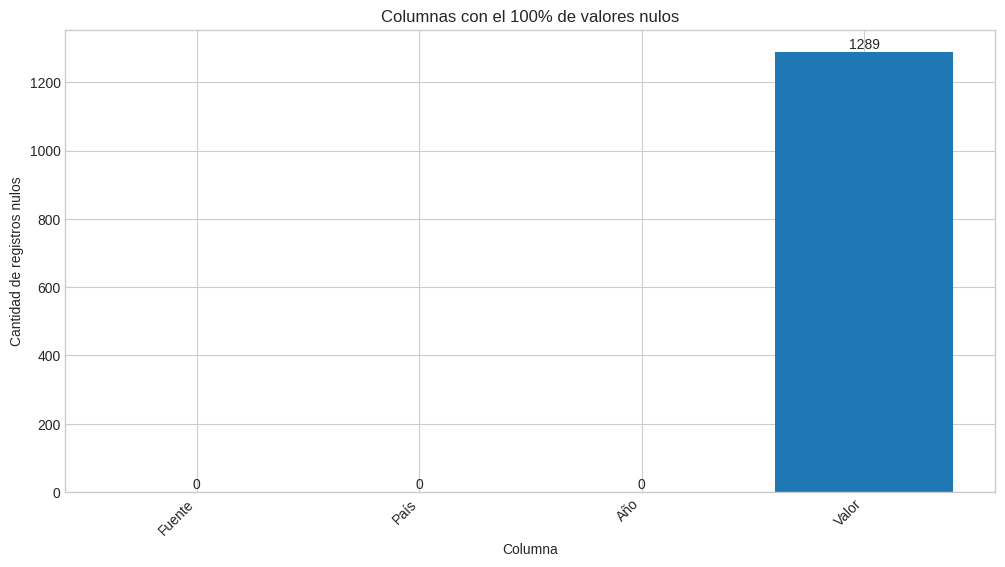

In [28]:
# Crear el DataFrame de análisis de nulos
nulos = pd.DataFrame({
    "Columna": df2_limpio.columns,
    "Cantidad de nulos": df2_limpio.isna().sum(),
    "Porcentaje de nulos": df2_limpio.isna().mean() * 100
})

# Configuración del gráfico de barras
plt.figure(figsize = (12, 6))
plt.bar(nulos["Columna"], nulos["Cantidad de nulos"])
plt.title("Columnas con el 100% de valores nulos")
plt.xlabel("Columna")
plt.ylabel("Cantidad de registros nulos")
plt.xticks(rotation=45, ha = "right")

# Mostrar el valor encima de cada barra
for i, valor in enumerate(nulos["Cantidad de nulos"]):
    plt.text(i, valor, str(valor), ha="center", va="bottom")

# Mostrar el gráfico
plt.show()

Un valor nulo es la ausencia de un valor o la falta de información de un dato, para este caso la columna valor tiene valores "nulos" que representa ciertas fuentes de energia, las cuales no registraron valores porque no se genero energia o en ese periodo de tiempo no existia la infraestructura requerida.

Estadisticas Descriptivas

In [29]:
# Tabla descriptiva por fuente
tabla_descriptiva = df2_limpio.groupby('Fuente')['Valor'].agg(
    Conteo='count',
    Nulos=lambda x: x.isna().sum(),
    Pct_Nulos=lambda x: (x.isna().sum() / len(x)) * 100,
    Media='mean',
    Desv_Estd='std',
    Minimo='min',
    Mediana='median',
    Maximo='max'
).round(2).reset_index()

# Mostrar la tabla formateada
display(tabla_descriptiva)

,Fuente,Conteo,Nulos,Pct_Nulos,Media,Desv_Estd,Minimo,Mediana,Maximo
0,Eólica,341,99,22.50,590.36,2212.80,0.00,21.15,20786.12
1,Geotermia,176,264,60.00,183.44,286.03,0.00,70.00,976.00
2,Hidro,440,0,0.00,7938.44,18333.35,40.90,1555.26,109413.21
3,Nuclear,146,294,66.82,707.27,822.49,0.00,0.00,2007.00
4,Otros,58,382,86.82,40.43,110.69,0.00,0.00,378.00
5,Solar,312,128,29.09,261.73,1140.90,0.00,1.57,13403.57
6,Total,440,0,0.00,15934.98,29121.49,201.35,4144.46,190574.49
7,Térmica no renovable,440,0,0.00,6457.32,10197.32,0.50,1848.84,55340.00
8,Térmica renovable,318,122,27.73,806.27,2535.04,0.00,121.80,16004.88


La tabla muestra el diagnostico del consumo por sector económico de los 20 paises observados durante el periodo analizado (2000-2021) se identifica:
* El consumo eléctrico máximo se identifica en 3 sectores clave como son comercial/servicios, industrial y residencial. El sector industrial es el principal sector de consumo con una media de 20.674.52 Gwh y una mediana de 3.470.25 Gwh
* Existe una marcada dispersión entre la media y la mediana en todos los sectores, esta brecha confirma la disparidad de la escala económica entre los paises de muestra.


/tmp/ipykernel_3083/3102755941.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_pais, x='Valor', y='País', palette='Blues_r')


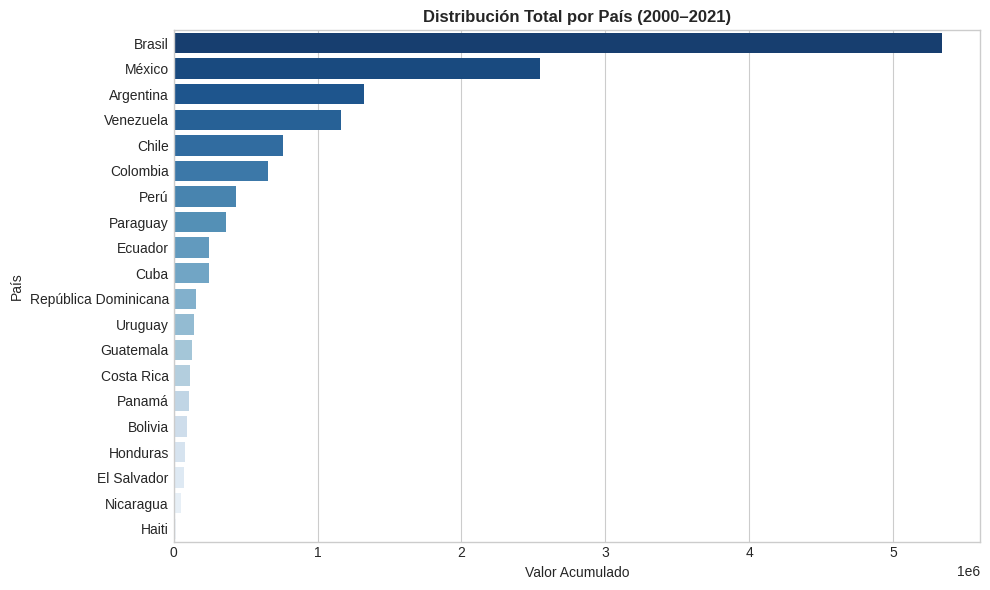

In [30]:
#distribucion por pais
dist_pais = df2_limpio.groupby('País')['Valor'].sum().reset_index()
dist_pais = dist_pais.sort_values('Valor', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=dist_pais, x='Valor', y='País', palette='Blues_r')

plt.title('Distribución Total por País (2000–2021)', fontweight='bold')
plt.xlabel('Valor Acumulado')
plt.tight_layout()
plt.show()

Se observa una Asimetría en la escala, la concentración máxima de generación, capacidad y consumo se encuentran en los Paises de Brasil y México.

Patrones temporales

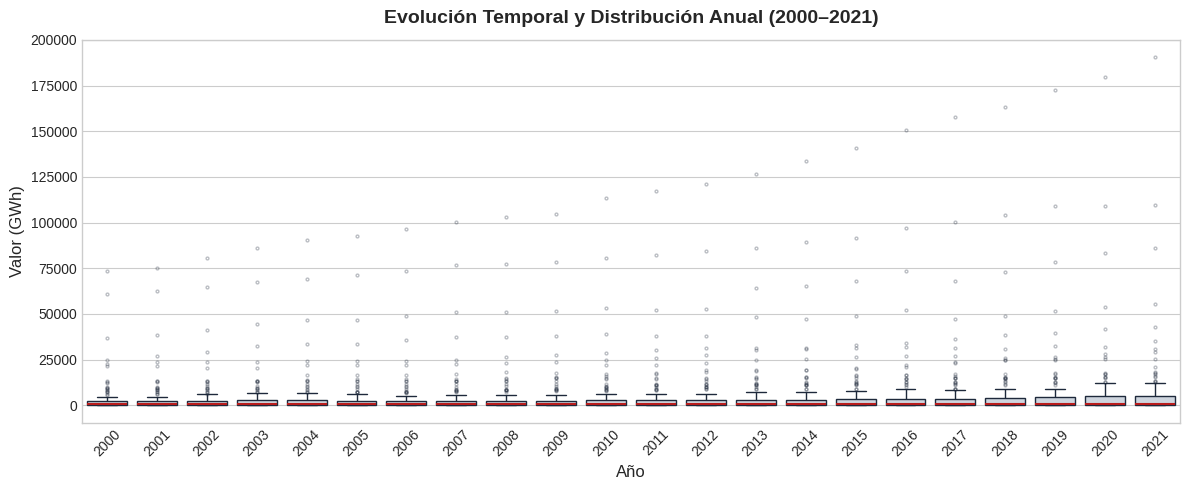

In [31]:
# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 5))

# Generar el Boxplot por Año
sns.boxplot(
    data=df2_limpio,
    x='Año',
    y='Valor',
    color='#cbd5e1',       # Color gris/azul pastel de relleno
    linecolor='#1e293b',   # Borde azul oscuro/gris
    medianprops={'color': '#b91c1c', 'linewidth': 1.5}, # Línea roja de la mediana
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3}, # Outliers sutiles
    ax=ax
)

# Títulos y etiquetas de los ejes
ax.set_title('Evolución Temporal y Distribución Anual (2000–2021)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Valor (GWh)', fontsize=12)

# Ajuste de rotación de las etiquetas
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Existe un comportamiento asimétrico que confirma que la mayoría de los paises y tecnologías alternas manejan volúmenes moderados. La dispersión de los puntos atípicos superiores representa el crecimiento masivo de la infraestructura energética en las potencias como Brasil y México.

## Hallazgos clave del EDA HOJA 2

1.  la presencia de datos nulos o faltantes indica tanto la  falta de infraestructura como inexistencia de la generación eléctrica por fuente en ciertos periodos de tiempo.
2. se observa una diferencia extrema entre las medias y las medianas esto refleja una brecha entre las potencias enérgicas industriales (Brasil y México) y las economías pequeñas delos demás paises observados.
3. Existe un comportamiento similar en la estructura de la hoja 1 y la  hoja 2
lo cual indica una relación de causalidad entre la generación y capacidad eléctrica


## Salida del script
Se guardarán los datos originales en un csv, para la fase de transformación que se trabajará en otro script.

In [32]:
ruta = "/content/drive/My Drive/Colab Notebooks/Master/1.ETL/entregable3/data/raw/"

# index = False; evita guardar el índice de pandas como una columna adicional
df2_limpio.to_csv(ruta + "HUB_capacidad_instalada.csv", sep = ";", index = False)

# HOJA 3 "Consumo "

In [33]:
# guardar dataset en la variable df3.
# crear un pandas dataframe, se usa pagina 'Capacidad_instalada'
df3 = pd.read_excel(ruta_xlsx, sheet_name='Consumo',skiprows=7)
# Visualizar dataframe.
df3.head()

,Indicador,Sector,País,Año,Valor,Unidad
0,Consumo de electricidad,Transporte,América Central,1970,12.000000,GWh
1,Consumo de electricidad,Transporte,América del Sur,1970,1195.229343,GWh
2,Consumo de electricidad,Transporte,América Latina y el Caribe,1970,1415.229343,GWh
3,Consumo de electricidad,Transporte,Argentina,1970,326.050000,GWh
4,Consumo de electricidad,Transporte,Barbados,1970,NaN,GWh


In [34]:
#Aplicacíon filtros
filtro_anos = df3['Año'].between(2000, 2021)
filtro_paises = df3['País'].isin(paises)
#Dataset filtrado
df3_filtrado = df3[filtro_anos & filtro_paises].copy()

Verificar numero de registros por cada País y total

In [35]:
# conteo original
print("Conteo total de registros para los 20 países:")
total_paises = df3_filtrado['País'].isin(paises).sum()
print(total_paises)
# Ver el número de registros por cada uno de los 20 países
print("\nRegistros por país:")
print(df3_filtrado[df3_filtrado['País'].isin(paises)]['País'].value_counts())

Conteo total de registros para los 20 países:
2640

Registros por país:
País
Argentina               132
Bolivia                 132
Brasil                  132
Chile                   132
Colombia                132
Costa Rica              132
Cuba                    132
Ecuador                 132
El Salvador             132
Guatemala               132
Haiti                   132
Honduras                132
México                  132
Nicaragua               132
Panamá                  132
Paraguay                132
Perú                    132
República Dominicana    132
Uruguay                 132
Venezuela               132
Name: count, dtype: int64


## Análisis Exploratorio de Datos (EDA) HOJA 3

Se realiza el EDA para tener mayor conocimiento sobre la información de la hoja 3 del dataset, a saber:


*   Cantidad de filas y columnas obtenidas
*   Tipos de datos y cantidad de registros por columnas
*   Registros nulos
*   Valores constantes
*   Unidades de medida
*   Estadísticas descriptivas
*   Patrones temporales

In [36]:
# Verificar la cantidad de registros y el número de columnas del dataframe df_filtrado
df3_filtrado.shape

(2640, 6)

Al final se obtienen 2640 registros con 6 columnas en la hoja 3.

In [37]:
# Conocer nombres de las columnas, cantidad de registros y tipos de datos del dataframe df_filtrado
df3_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2640 entries, 1023 to 10946
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Indicador  2640 non-null   object 
 1   Sector     2640 non-null   object 
 2   País       2640 non-null   object 
 3   Año        2640 non-null   int64  
 4   Valor      2082 non-null   float64
 5   Unidad     2640 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 144.4+ KB


El dataset Consumo se compone de:


*   Indicador : De tipo descriptivo "Consumo de electricidad" .
*   Sector: sector donde se realiza el consumo energetico" Transporte - Industrial- Residencial - Comercial, servicios, publico - Agro, pesca, mineria - Construcción, otros".
*   País: Nombre del país.
*   Año:  Año de registro.
*  Valor: Cantidad de energía generada.
*  Unidad: unidad en la que fue medida GMW.

se eliminan columnas redundantes o que no aportan información relevante al EDA

Eliminación de Ruido

In [38]:
# eliminar columnas redundantes
df3_limpio = df3_filtrado.drop(columns=['Indicador','Unidad'])
# Verificar la cantidad de registros y el número de columnas del dataframe df_limpio
df3_limpio.shape

(2640, 4)

In [39]:
# Generar perfilamiento de datos con Pandas Profiling
# nombre unico
nombre_archivo = f"reporte_Consumo_energetico_{int(time.time())}.html"
profile = ProfileReport(df3_limpio, title="Análisis Exploratorio - Consumo_energetico- Dataset")
profile.to_file(nombre_archivo)
#mostar datset
#profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 40.82it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Ver valores faltantes o nulos

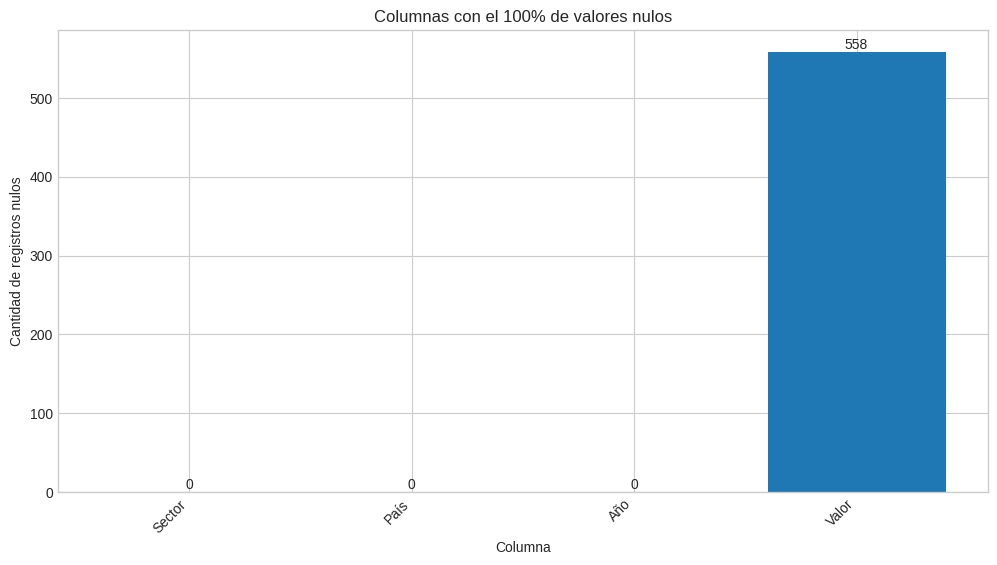

In [40]:
# Crear el DataFrame de análisis de nulos
nulos = pd.DataFrame({
    "Columna": df3_limpio.columns,
    "Cantidad de nulos": df3_limpio.isna().sum(),
    "Porcentaje de nulos": df3_limpio.isna().mean() * 100
})

# Configuración del gráfico de barras
plt.figure(figsize = (12, 6))
plt.bar(nulos["Columna"], nulos["Cantidad de nulos"])
plt.title("Columnas con el 100% de valores nulos")
plt.xlabel("Columna")
plt.ylabel("Cantidad de registros nulos")
plt.xticks(rotation=45, ha = "right")

# Mostrar el valor encima de cada barra
for i, valor in enumerate(nulos["Cantidad de nulos"]):
    plt.text(i, valor, str(valor), ha="center", va="bottom")

# Mostrar el gráfico
plt.show()

Un valor nulo es la ausencia de un valor o la falta de información de un dato, para este caso la columna valor tiene valores "nulos" que representa ciertas fuentes de energia, las cuales no registraron valores porque no se genero energia o en ese periodo de tiempo no existia la infraestructura requerida.

In [41]:
# Tabla descriptiva por fuente
tabla_descriptiva = df3_limpio.groupby('Sector')['Valor'].agg(
    Conteo='count',
    Nulos=lambda x: x.isna().sum(),
    Pct_Nulos=lambda x: (x.isna().sum() / len(x)) * 100,
    Media='mean',
    Desv_Estd='std',
    Minimo='min',
    Mediana='median',
    Maximo='max'
).round(2).reset_index()

# Mostrar la tabla formateada
display(tabla_descriptiva)

,Sector,Conteo,Nulos,Pct_Nulos,Media,Desv_Estd,Minimo,Mediana,Maximo
0,"Agro, pesca y minería",307,133,30.23,5880.69,10078.23,0.14,729.76,46989.52
1,"Comercial, servicios, público",440,0,0.00,11155.27,24049.49,22.00,2859.06,140855.45
2,Construcción y otros,237,203,46.14,4905.09,12572.29,0.56,371.94,83496.82
3,Industrial,440,0,0.00,20674.52,40458.33,67.29,3470.25,175268.28
4,Residencial,440,0,0.00,15273.74,26782.69,84.64,4254.89,151130.03
5,Transporte,218,222,50.45,454.35,552.23,0.08,239.32,2055.19


La tabla muestra el diagnostico del consumo por sector económico de los 20 paises observados durante el periodo analizado (2000-2021) se identifica:

*	El consumo eléctrico máximo se identifica en 3 sectores clave como son comercial/servicios, industrial y residencial. El sector industrial es el principal sector de consumo con una media de 20.674.52 Gwh y una mediana de 3.470.25 Gwh
*	Existe una marcada dispersión entre la media y la mediana en todos los sectores, esta brecha confirma la disparidad de la escala económica entre los paises de muestra.


/tmp/ipykernel_3083/3102755941.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_pais, x='Valor', y='País', palette='Blues_r')


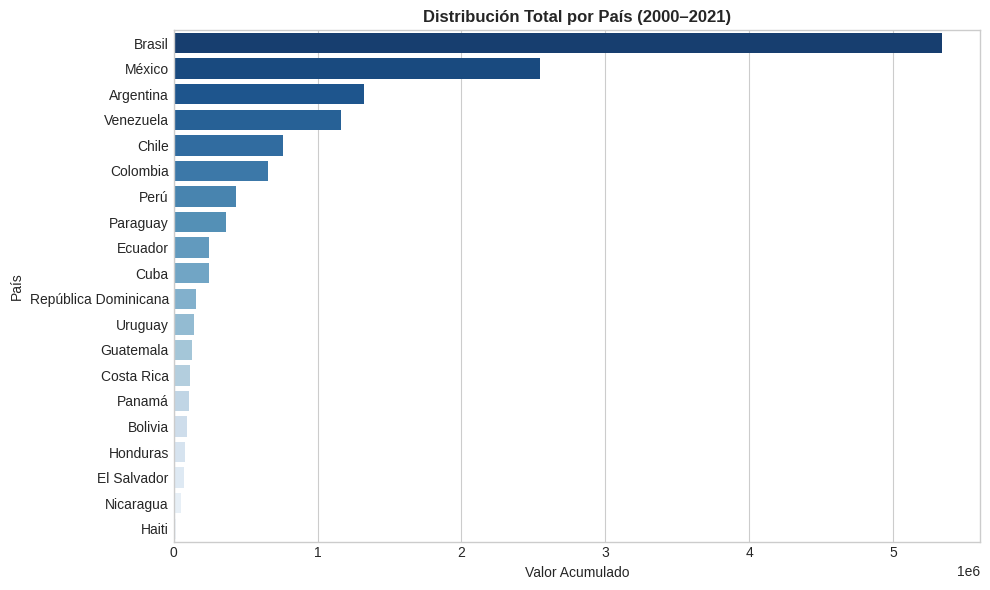

In [42]:
#distribucion por pais
dist_pais = df2_limpio.groupby('País')['Valor'].sum().reset_index()
dist_pais = dist_pais.sort_values('Valor', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=dist_pais, x='Valor', y='País', palette='Blues_r')

plt.title('Distribución Total por País (2000–2021)', fontweight='bold')
plt.xlabel('Valor Acumulado')
plt.tight_layout()
plt.show()

Se observa una Asimetría en la escala, la concentración máxima de generación, capacidad y consumo se encuentran en los Paises de Brasil y México.

Patrones temporales

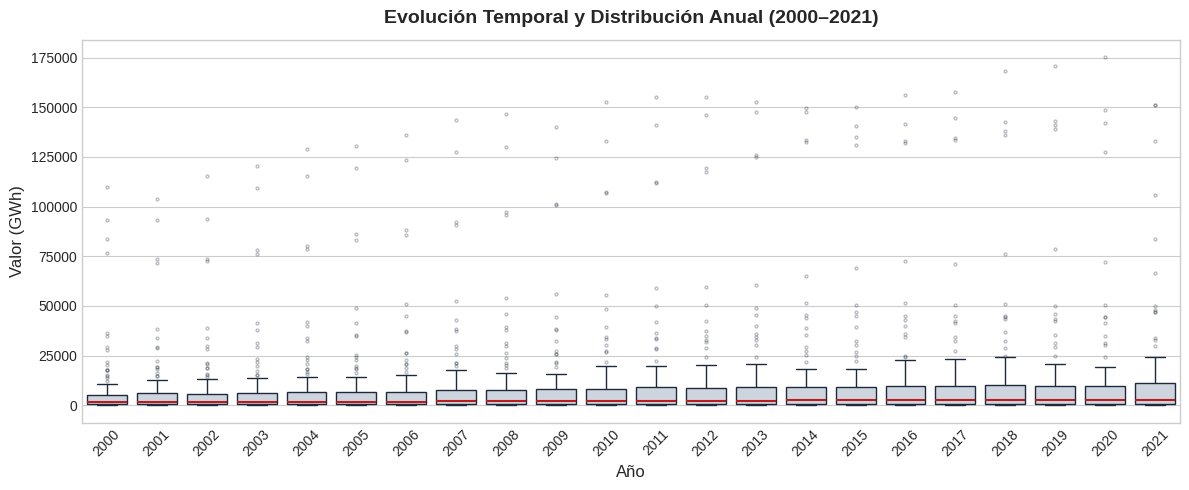

In [43]:
# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 5))

# Generar el Boxplot por Año
sns.boxplot(
    data=df3_limpio,
    x='Año',
    y='Valor',
    color='#cbd5e1',       # Color gris/azul pastel de relleno
    linecolor='#1e293b',   # Borde azul oscuro/gris
    medianprops={'color': '#b91c1c', 'linewidth': 1.5}, # Línea roja de la mediana
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3}, # Outliers sutiles
    ax=ax
)

# Títulos y etiquetas de los ejes
ax.set_title('Evolución Temporal y Distribución Anual (2000–2021)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Valor (GWh)', fontsize=12)

# Ajuste de rotación de las etiquetas
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Existe un comportamiento asimétrico que confirma que la mayoría de los paises y tecnologías alternas manejan volúmenes moderados. La dispersión de los puntos atípicos superiores representa el crecimiento masivo de la infraestructura energética en las potencias como Brasil y México.

## Hallazgos clave del EDA HOJA 3

1.  la presencia de datos nulos o faltantes indica tanto la  falta de infraestructura como inexistencia de la generación eléctrica por fuente en ciertos periodos de tiempo.
2. se observa una diferencia extrema entre las medias y las medianas esto refleja una brecha entre las potencias enérgicas industriales (Brasil y México) y las economías pequeñas delos demás paises observados.



## Salida del script
Se guardarán los datos originales en un csv, para la fase de transformación que se trabajará en otro script.

In [44]:
ruta = "/content/drive/My Drive/Colab Notebooks/Master/1.ETL/entregable3/data/raw/"

# index = False; evita guardar el índice de pandas como una columna adicional
df3_limpio.to_csv(ruta + "extract_HUB_consumo.csv", sep = ";", index = False)